# Автоматическая кластеризация физических сигналов сцинтилляционного детектора

Целью данного проекта является разработка и оформление решения по автоматической кластеризации экспериментальных сигналов, полученных со сцинтилляционного детектора на основе органических кристаллов паратерфенила. 

Необходимо разделить 23 479 сигналов (каждый содержит по 500 временных отсчетов амплитуды) на три непересекающихся кластера:
* **Кластер 0:** Первый тип физических частиц (гамма-кванты).
* **Кластер 1:** Второй тип физических частиц (нейтроны).
* **Кластер 2:** Аномальные, неидентифицируемые сигналы и аппаратный шум.

Итоговое качество разметки оценивается на платформе Kaggle с помощью метрики **Accuracy**. Результат работы должен быть полностью воспроизводимым.

## 1. Исследование и анализ датасета (EDA)

### 1.1 Инициализация окружения и загрузка данных

Загрузим данные и отделим служебные колонки от самих сигналов.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df = pd.read_csv('Run200_Wave_0_1.txt', sep=r'\s+', header=None)

df_meta = df.iloc[:, :4]
df_signals = df.iloc[:, 4:]

print(df.shape)
print(df_signals.shape)

display(df_signals.head())

(23479, 504)
(23479, 500)


,4,5,6,7,8,9,10,11,12,13,...,494,495,496,497,498,499,500,501,502,503
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


**Вывод:**

После разделения данных в таблице df_signals осталось 23 479 строк и 500 колонок с сигналами.

Служебные колонки были отделены в df_meta.

### 1.2 Проверка данных на пропуски и дубликаты

Сначала проверим, есть ли в данных пропуски и повторяющиеся строки.

In [2]:
print(df_signals.isna().sum().sum())
print(df_signals.duplicated().sum())

0
0


**Вывод:**

В таблице df_signals не найдено пропусков и дубликатов.

* Количество пропусков: 0
* Количество дубликатов: 0

### 1.3 Графики физических сигналов

Построим графики нескольких сигналов и посмотрим на их форму.

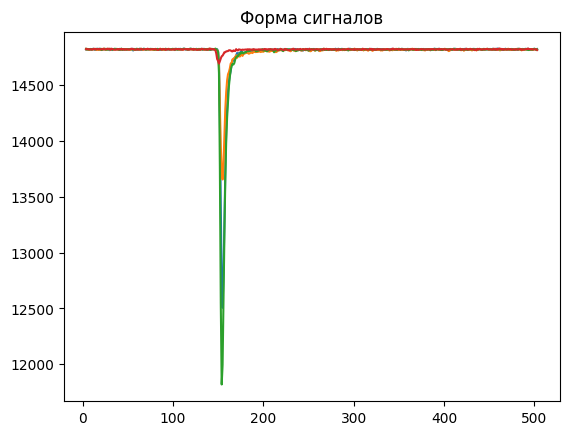

In [3]:
sample_signals = df_signals.sample(4, random_state=42)

plt.plot(sample_signals.T)
plt.title('Форма сигналов')

plt.show()

**Вывод:**

На графиках видно, что сигналы имеют похожую форму.

Во всех примерах наблюдается резкое изменение сигнала примерно в середине графика, после чего сигнал постепенно возвращается к исходному уровню.

Также заметно, что глубина и скорость восстановления у сигналов немного отличаются.

### Общий вывод по разделу 1

После загрузки данных было обнаружено, что таблица содержит 504 колонки. Первые 4 колонки относятся к служебной информации, поэтому для дальнейшего анализа были оставлены только 500 колонок с сигналами.

В итоговой таблице находится 23 479 строк. Проверка показала, что пропуски и дубликаты отсутствуют.

Построенные графики сигналов показали похожую форму импульсов. Во всех случаях наблюдается резкое изменение сигнала и дальнейшее постепенное восстановление к исходному уровню.

Также видно, что сигналы отличаются по глубине и скорости затухания. Это говорит о том, что форму импульсов можно использовать для разделения сигналов на группы.

## 2. Предобработка данных

На этом шаге уберём фоновый уровень сигнала и отдельно отметим аномальные строки. Для шума возьмём среднее значение первых 50 точек.

In [4]:
baseline = df_signals.iloc[:, :50].mean(axis=1)

df_centered = df_signals.copy()

for col in df_centered.columns:
    df_centered[col] = df_centered[col] - baseline

df_centered = df_centered.clip(lower=0)

raw_amplitudes = df_centered.max(axis=1)
raw_areas = df_centered.sum(axis=1)

area_thresh = raw_areas.quantile(0.99)
amp_thresh = raw_amplitudes.quantile(0.01)

anomaly_mask = (raw_areas > area_thresh) | (raw_amplitudes < amp_thresh)

final_clusters = np.full(len(df), -1)
final_clusters[anomaly_mask] = 2

df_normal_signals = df_centered[~anomaly_mask].copy()

print(np.sum(anomaly_mask))
print(df_normal_signals.shape)

458
(23021, 500)


### Вывод по разделу 2

После вычитания фонового уровня сигналы были приведены к единой нулевой линии.

По порогам площади и амплитуды было найдено 458 аномальных сигналов. Эти строки сразу отнесены к кластеру 2.

После удаления аномалий для дальнейшей работы осталось 23 021 строк и 500 точек сигнала.

## 3. Выделение признаков (Feature Engineering)

На этом шаге сделаем из каждого сигнала несколько числовых признаков: амплитуду, площадь и PSD.

In [5]:

X_normal_features = pd.DataFrame(index=df_normal_signals.index)

X_normal_features['amplitude'] = df_normal_signals.max(axis=1)
X_normal_features['total_area'] = df_normal_signals.sum(axis=1)

tail_area = df_normal_signals.iloc[:, 136:].sum(axis=1)
X_normal_features['psd'] = tail_area / (X_normal_features['total_area'] + 0.0001)

print(X_normal_features.shape)
display(X_normal_features.head(3))

(23021, 3)


,amplitude,total_area,psd
0,8.52,318.88,0.621550
1,5.52,306.20,0.561202
2,8.10,312.70,0.574672


## Вывод по разделу 3 (Feature Engineering):

Для каждого сигнала были рассчитаны 3 признака: amplitude, total_area и psd.

Итоговая таблица признаков содержит 23 021 строку и 3 колонки.

По первым строкам видно, что значения признаков отличаются: например, amplitude принимает значения 8.52, 5.52, 8.10, а psd - 0.621550, 0.561202, 0.574672.

Эти признаки дальше можно использовать для кластеризации сигналов.

## 4. Анализ признаков и оценка важности

Посмотрим распределение признаков и проверим связи между ними.

            amplitude  total_area   psd
amplitude        1.00        0.38  0.29
total_area       0.38        1.00  0.83
psd              0.29        0.83  1.00


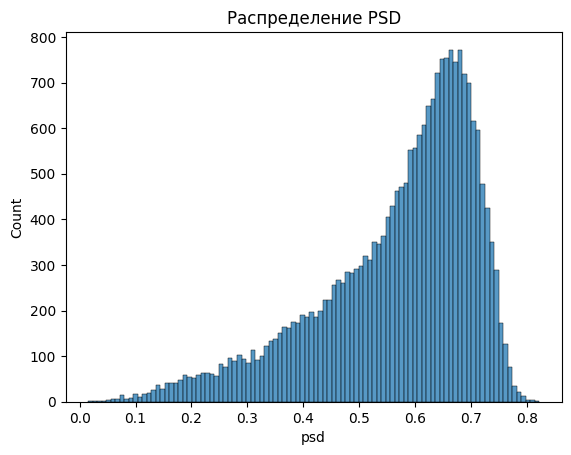

In [6]:
print(X_normal_features.corr().round(2))

sns.histplot(data=X_normal_features, x='psd', bins=100)

plt.title('Распределение PSD')

plt.show()

### Вывод по разделу 4:

Корреляция показала, что total_area и psd связаны сильнее всего (0.83).

Связь amplitude с другими признаками заметно слабее: 0.38 и 0.29.

На графике распределения psd видно, что значения распределены неравномерно и образуют несколько областей концентрации.

Это говорит о том, что признак psd может быть полезен для разделения сигналов на группы.

## 5. Обучение нескольких моделей, их сравнение

### 5.1 Масштабирование признаков перед обучением

Перед обучением приведём признаки к одному масштабу.

In [7]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X_normal_features))
X_scaled.columns = X_normal_features.columns
X_scaled.index = X_normal_features.index

display(X_scaled.head(3))

,amplitude,total_area,psd
0,0.506024,-0.297037,0.083513
1,-1.301205,-0.371590,-0.249262
2,0.253012,-0.333373,-0.174983


**Вывод**

Признаки были приведены к одному масштабу с помощью RobustScaler.

После масштабирования таблица X_scaled сохранила те же 3 признака: amplitude, total_area и psd.

По первым строкам видно, что значения стали сопоставимыми между собой: например, amplitude принимает значения: 0.506024, -1.301205, 0.253012, а psd: 0.083513, -0.249262, -0.174983.

Теперь данные можно использовать для обучения моделей кластеризации.

### 5.2 Обучение алгоритма K-Means

Обучим модель K-Means на подготовленных признаках.

In [8]:
from sklearn.cluster import KMeans

model_km = KMeans(n_clusters=2, random_state=42)

km_labels = model_km.fit_predict(X_scaled)

print(km_labels[:10])

[1 0 1 1 1 1 0 1 1 0]


**Вывод**

Модель K-Means разделила сигналы на 2 кластера.

Для каждого сигнала был рассчитан номер кластера - 0 или 1.

Первые 10 результатов кластеризации:
`[1 0 1 1 1 1 0 1 1 0]`

Полученные метки будут использоваться для дальнейшего сравнения моделей и оценки качества кластеризации.

### 5.3 Обучение алгоритма MiniBatchKMeans

Обучим ещё одну модель кластеризации - MiniBatchKMeans.

In [9]:
from sklearn.cluster import MiniBatchKMeans

model_mb = MiniBatchKMeans(
    n_clusters=2,
    random_state=42,
    batch_size=2048
)

mb_labels = model_mb.fit_predict(X_scaled)

print(mb_labels[:10])

[0 1 1 0 0 0 1 0 0 1]


**Вывод**

Модель MiniBatchKMeans также разделила сигналы на 2 кластера.

Для каждого сигнала был рассчитан номер группы - 0 или 1.

Первые 10 результатов:
`[0 1 1 0 0 0 1 0 0 1]`

Теперь можно сравнить результаты K-Means и MiniBatchKMeans.

### 5.4 Обучение модели Gaussian Mixture (GMM)

Обучим модель Gaussian Mixture.

In [10]:
from sklearn.mixture import GaussianMixture

model_gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_labels = model_gmm.fit_predict(X_scaled)

print(gmm_labels[:10])

[1 0 1 1 1 1 1 1 1 0]


**Вывод**

Модель GaussianMixture разделила сигналы на 2 группы.

Для каждого сигнала был рассчитан номер кластера - 0 или 1.

Первые 10 результатов:
`[1 0 1 1 1 1 1 1 1 0]`

Теперь результаты GaussianMixture можно сравнить с K-Means и MiniBatchKMeans.

### 5.5 Сводная таблица и сравнение моделей

Сравним результаты моделей с помощью метрик кластеризации.

In [11]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

idx = np.random.choice(len(X_scaled), size=5000, replace=False)

X_sample = X_scaled.iloc[idx]

results = {
    'Модель': [
        'K-Means',
        'MiniBatchKMeans',
        'Gaussian Mixture'
    ],

    'Silhouette': [
        silhouette_score(X_sample, km_labels[idx]),
        silhouette_score(X_sample, mb_labels[idx]),
        silhouette_score(X_sample, gmm_labels[idx])
    ],

    'Calinski-Harabasz': [
        calinski_harabasz_score(X_sample, km_labels[idx]),
        calinski_harabasz_score(X_sample, mb_labels[idx]),
        calinski_harabasz_score(X_sample, gmm_labels[idx])
    ]
}

df_metrics = pd.DataFrame(results)

display(df_metrics.round(4))

,Модель,Silhouette,Calinski-Harabasz
0,K-Means,0.3971,4166.1654
1,MiniBatchKMeans,0.3924,4056.3469
2,Gaussian Mixture,0.3803,3643.1144


**Вывод по разделу 5:**

Были обучены и сравнены 3 модели кластеризации:

* K-Means
* MiniBatchKMeans
* Gaussian Mixture

Лучшие результаты показала модель K-Means.

Для неё:

* Silhouette = 0.3971
* Calinski-Harabasz = 4166.1654
* У остальных моделей значения метрик оказались ниже.

Поэтому для дальнейшей кластеризации была выбрана модель K-Means.

## 6. Подбор гиперпараметров (выбор числа кластеров)

Подберём количество кластеров с помощью метода локтя.

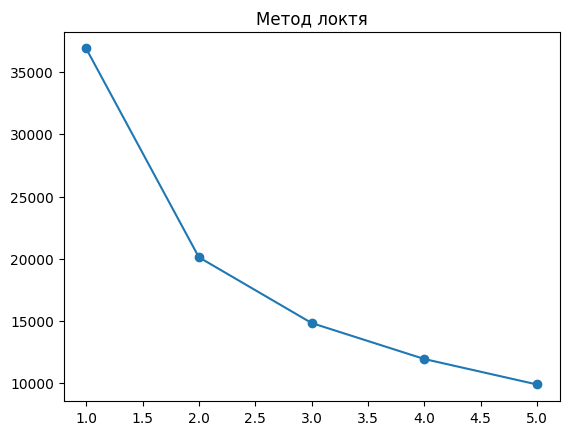

In [12]:
wcss = []

for k in range(1, 6):
    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.plot(range(1, 6), wcss, marker='o')

plt.title('Метод локтя')

plt.show()

### Вывод по разделу 6:

* График показал резкое уменьшение ошибки при переходе от 1 к 2 кластерам.
* После k=2 снижение ошибки становится более плавным.

Это говорит о том, что оптимальное количество кластеров для данных - 2.

## 7. Выбор лучшей модели

После сравнения моделей для итоговой кластеризации была выбрана модель K-Means.

Причины выбора:

* модель показала лучшие значения метрик Silhouette и Calinski-Harabasz;
* метод локтя показал, что оптимальное количество кластеров равно 2;
* модель стабильно разделяет сигналы на две группы.

### Вывод по разделу 7

После сравнения моделей и подбора параметров для итоговой кластеризации была выбрана модель K-Means с двумя кластерами.

Эта модель показала лучшие результаты по метрикам качества и будет использоваться для формирования итогового файла предсказаний.

## 8. Предсказание

### 8.1 Финальное предсказание и физическая разметка классов

Обучим финальную модель и получим итоговые предсказания.

In [13]:
model_final = KMeans(
    n_clusters=2,
    random_state=42
)

X_normal_features['cluster_pred'] = model_final.fit_predict(X_scaled)

mean_0 = X_normal_features[
    X_normal_features['cluster_pred'] == 0
]['psd'].mean()

mean_1 = X_normal_features[
    X_normal_features['cluster_pred'] == 1
]['psd'].mean()

if mean_0 > mean_1:
    X_normal_features['mapped_cluster'] = (
        1 - X_normal_features['cluster_pred']
    )
else:
    X_normal_features['mapped_cluster'] = (
        X_normal_features['cluster_pred']
    )

**Вывод**

Финальная модель K-Means разделила сигналы на 2 группы.

Дополнительно была выполнена проверка среднего значения psd для каждого кластера.

После этого номера кластеров были приведены к итоговой разметке классов.

### 8.2 Сохранение результатов для Kaggle

Соберём итоговую таблицу и сохраним её в файл submission.csv.

In [14]:
final_clusters[~anomaly_mask] = X_normal_features['mapped_cluster']

submission = pd.DataFrame({
    'index': df.index,
    'cluster': final_clusters
})

print(submission['cluster'].value_counts())

submission.to_csv('submission_initial.csv', index=False)

cluster
1    13985
0     9036
2      458
Name: count, dtype: int64


**Вывод**

Итоговый файл submission_initial.csv был создан.

В нём 23 479 строк и 2 колонки: index и cluster.

Распределение по кластерам получилось следующим:

* кластер 1 - 13 985 сигналов;
* кластер 0 - 9 036 сигналов;
* кластер 2 - 458 сигналов.

Файл готов для загрузки на Kaggle.

## 9. Общие выводы и итоги работы

### 9.1 Результаты кластеризации

В ходе работы все 23 479 сигналов были разделены на 3 группы:
1. Кластер 0 - 9 036 сигналов.
   Для этой группы характерны меньшие значения признака psd.
2. Кластер 1 - 13 985 сигналов.
   У сигналов этого кластера значения psd оказались выше.
3. Кластер 2 - 458 сигналов.
   В этот кластер были отнесены аномальные сигналы, найденные на этапе очистки данных.

### 9.2 Итоги работы с точки зрения машинного обучения

В ходе проекта были выполнены основные этапы предобработки и кластеризации данных:
* удаление служебных колонок;
* очистка сигналов;
* выделение признаков;
* масштабирование данных;
* обучение и сравнение нескольких моделей кластеризации.

Для каждого сигнала были рассчитаны 3 признака:
* amplitude
* total_area
* psd

После сравнения моделей лучшие результаты показал алгоритм K-Means.

Метод локтя также подтвердил, что оптимальное количество кластеров для данных равно 2.

В результате был создан итоговый файл submission_initial.csv, готовый для загрузки на Kaggle.

## Скриншот результата на Kaggle

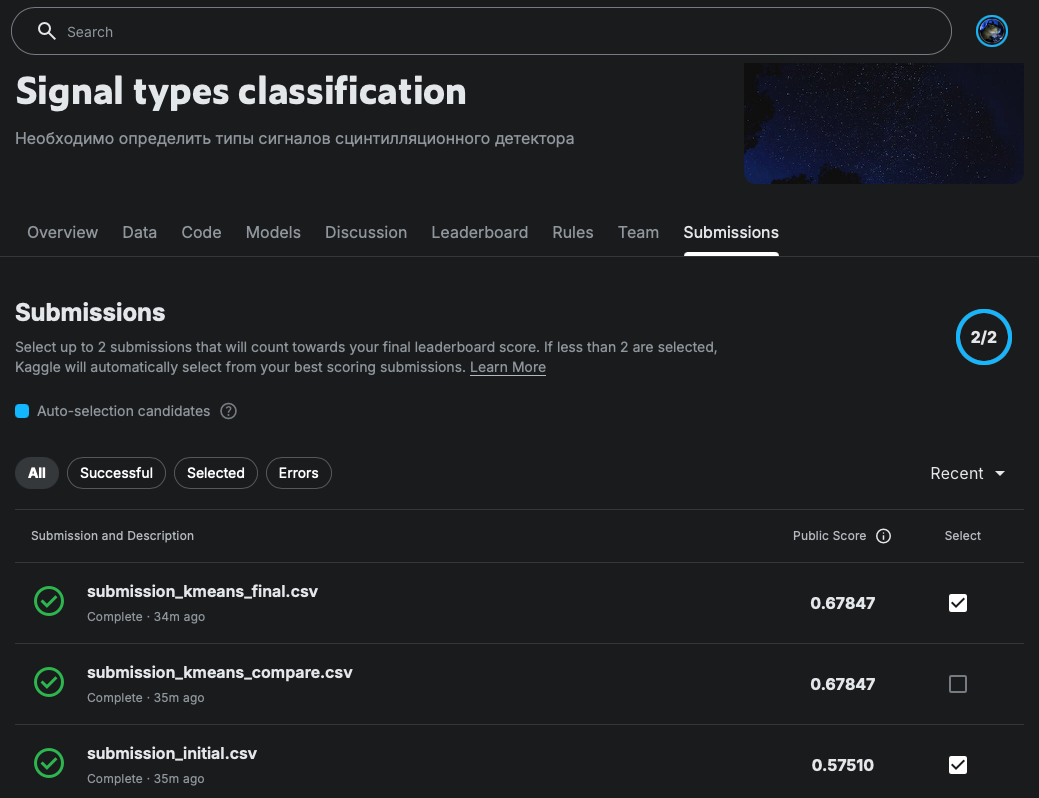